In [10]:
import numpy as np

for i in range(1, 11):
    print(i, i * np.pi / 2, f"{i * np.pi:.2e}")

1 1.5707963267948966 3.14e+00
2 3.141592653589793 6.28e+00
3 4.71238898038469 9.42e+00
4 6.283185307179586 1.26e+01
5 7.853981633974483 1.57e+01
6 9.42477796076938 1.88e+01
7 10.995574287564276 2.20e+01
8 12.566370614359172 2.51e+01
9 14.137166941154069 2.83e+01
10 15.707963267948966 3.14e+01


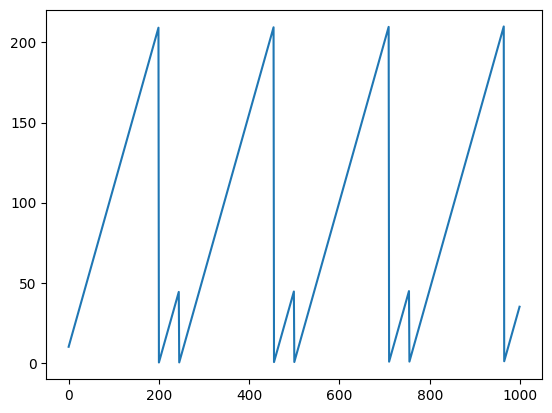

In [2]:
import matplotlib.pyplot as plt
import torch

x = y = torch.linspace(-0.5, 0.5, 1000)
X, Y = torch.meshgrid(x, y)

Y = ((1000 * Y) % 255) % 210
plt.plot(Y[0, :])

In [1]:
from fiatlux.optical_elements.mask import CircularAperture
from fiatlux.grid import Grid
from fiatlux.spectrum import *
from fiatlux.source import *
from fiatlux.propagator import MFTPropagator
from fiatlux.optical_elements.mask import ZeldaMask, ZeldaStop
from fiatlux.utils.converter import FocalPlaneConverter
from fiatlux.optical_elements.field_stop import ShanonFieldStop

from fiatlux.optical_elements.deformable_mirror import (
    DeformableMirror,
    ActuatorGrid,
    InteractionMatrix,
)
from fiatlux.optical_elements.mask import ADC as ADCMask

from fiatlux.utils.zernike import zernike_basis

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ModuleNotFoundError: No module named 'fiatlux.optical_elements.mask'

In [1]:
import matplotlib.pyplot as plt
import pysynphot as S

obs = S.Observation(S.BlackBody(5000), S.ObsBandpass("johnson,v"))
plt.plot(obs.binwave, obs.binflux, drawstyle="steps-mid")
plt.xlim(4000, 7000)
plt.xlabel(obs.waveunits)
plt.ylabel(obs.fluxunits)
plt.title(obs.name)

/Users/pjanin/Documents/GitHub/fiatlux/.venv/lib/python3.13/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/Users/pjanin/Documents/GitHub/fiatlux/.venv/lib/python3.13/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))
/Users/pjanin/Documents/GitHub/fiatlux/.venv/lib/python3.13/site-packages/pysynphot/refs.py:117: UserWarning: No graph or component tables found; functionality will be SEVERELY crippled. No files found for https://ssb.stsci.edu/trds/mtab/*_tmg.fits
  warnings.warn('No graph or component tables found; '
/Users/pjanin/Documents/GitHub/fiatlux/.venv/lib/python3.13/site-packages/pysynphot/refs.py:124: UserWarning: No thermal tables found, no thermal calculations can be performed. No files found for https://ssb.stsci.edu/tr

TypeError: initializing GraphTable with GFile=None; possible bad/missing PYSYN_CDBS

In [3]:
print(fb.build_command_matrix().shape)
print(zb.build_command_matrix().shape)

torch.Size([16384, 198])
torch.Size([16384, 99])


/Users/pjanin/Documents/GitHub/fiatlux/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [4]:
512 * 512

262144

In [5]:
adc = ADC()
spectrum = Spectrum.from_sampling(9, PhotometricBand.HCM2, Nu=512)
lod = spectrum.wavelengths.max() / 39.542
amp = torch.deg2rad(adc.get_dispersion(53, spectrum) / 3600)
print(amp)
print(amp / (lod))

NameError: name 'ADC' is not defined

In [ ]:
m = ADCMask(amp, 90)

D = 39.542
# Pupil plane sampling
Nx = Ny = 128
dx = dy = D / Nx
pupil_grid = Grid(nx=Nx, ny=Ny, dx=dx, dy=dx)
m.build(grid=pupil_grid, spectrum=spectrum)

In [ ]:
spectrum = Spectrum.from_sampling(PhotometricBand.HCM, Nu=512)

# System parameters
f = 0.125
lambda_max = spectrum.wavelengths.max()
D = 10

tip = 0 * (2 * torch.pi * lambda_max / D)
tilt = 0 * (2 * torch.pi * lambda_max / D)

adc_amplitude = 0 * (2 * torch.pi / D)
adc_angle = 90 * torch.pi / 180

theta = lambda_max / 4

# Pupil plane sampling
Nx = Ny = 128
dx = dy = D / Nx
pupil_grid = Grid(nx=Nx, ny=Ny, dx=dx, dy=dx)

# Focal plane sampling
Nu = Nv = 512
# # Shanon
# du = dv = Nx * (f * l / D) / Nu
du = dv = (10) * (f * lambda_max / D) / (Nu / 2)
focal_grid = Grid(nx=Nu, ny=Nv, dx=du, dy=dv)

# Create source
source = PlaneWave(
    spectrum=spectrum,
    incidence_angle=IncidenceAngle(tip=tip, tilt=tilt),
)

# Create aperture
aperture = CircularAperture(radius=D / 2)

# Create ADC
adc = ADC(adc_amplitude, adc_angle)
adc.build(pupil_grid, spectrum)

# Create DM
dm = DeformableMirror(
    0, ActuatorGrid(10, 10, 1.0), pupil_grid, stroke=2e0, influence_width=0.5
)
dm._commands = torch.rand(100)
plt.imshow(dm.phase)

# Define propagator
mft = MFTPropagator(focal_length=f)

# Define zelda mask
zelda_mask = ZeldaMask(radius=f * lambda_max / D, well_depth=theta)


zelda_stop = ZeldaStop(radius=f * lambda_max / D, well_depth=theta)


stop = FieldStop()
stop.apply()

TypeError: Spectrum.from_sampling() missing 1 required positional argument: 'band'

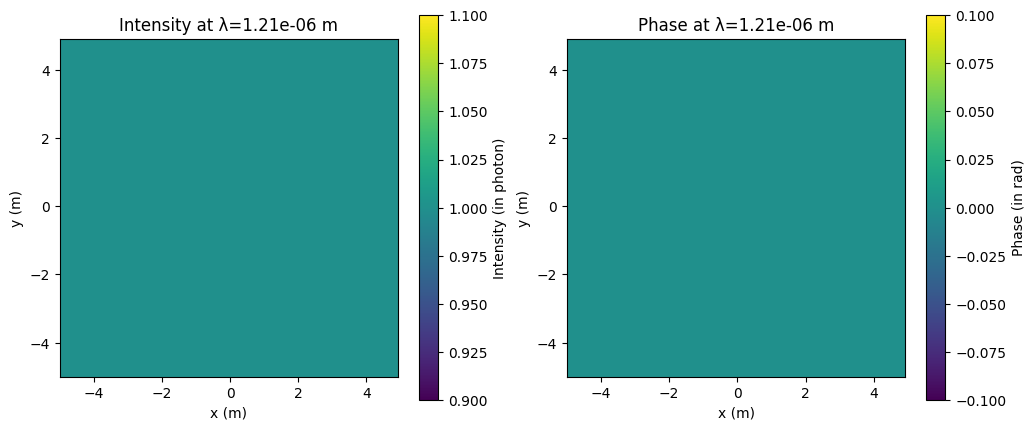

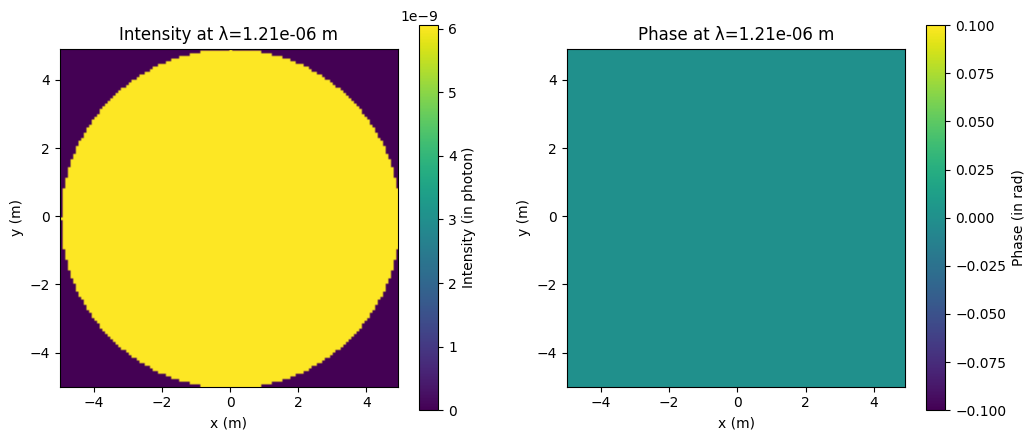

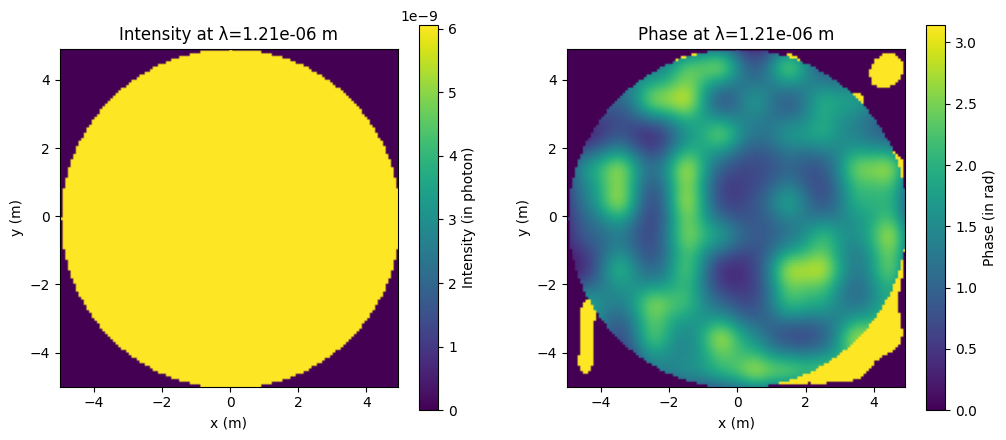

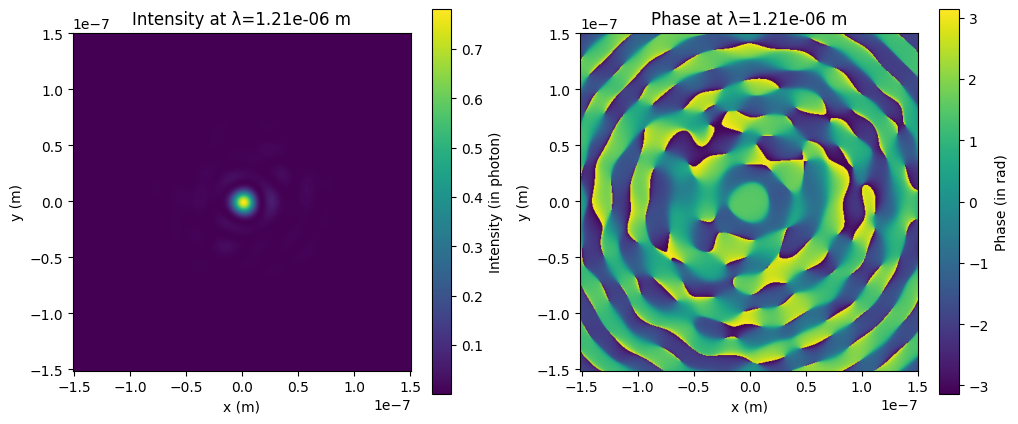

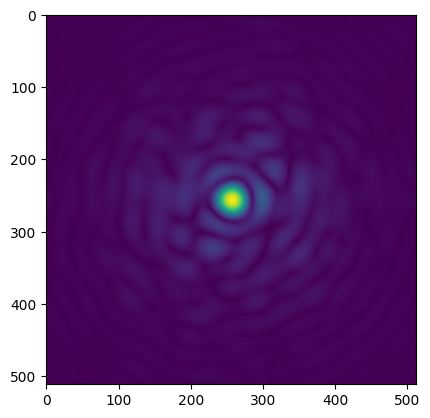

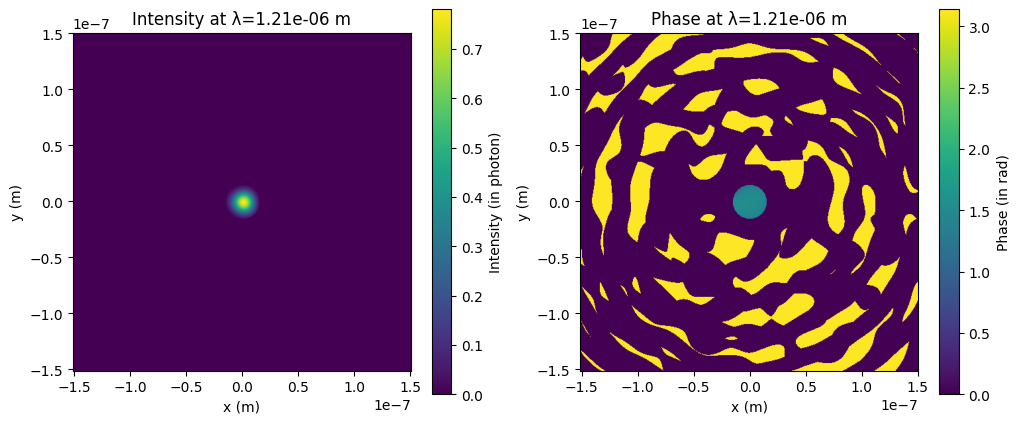

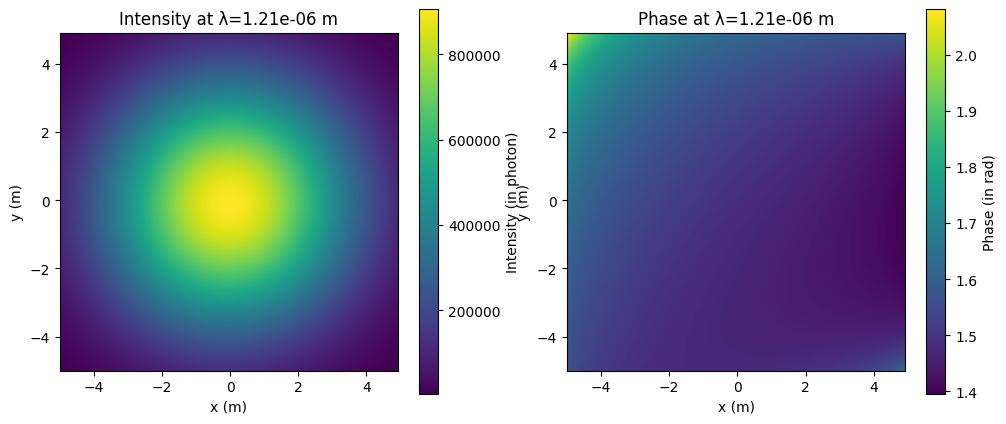

In [ ]:
# Create input field
field = source.generate_field(pupil_grid)
field.plot()

# Apply aperture
field = aperture.apply(field)
field.plot()

# # Apply ADC
# field = adc.apply(field)
# field.plot()

# Apply DM
field = dm.apply(field)
field.plot()

aperture_field = field


# Propagate to focal plane
field = mft.propagate(field, focal_grid)
field.plot()

# Apply aperture
field = zelda_stop.apply(field)
field.plot()

# Propagate to pupil plane
field = mft.propagate(field, pupil_grid)
field.plot()
b = field

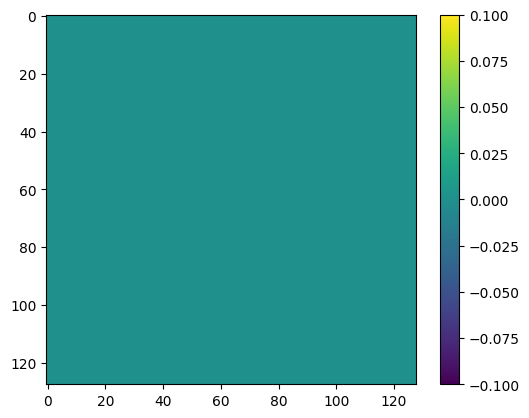

In [ ]:
plt.imshow(
    torch.angle(aperture_field.complex_amplitude[-1])
    - torch.angle(aperture_field.complex_amplitude[0])
)
plt.colorbar()

In [ ]:
Phi = aperture.apply(aperture_field - (1 - torch.exp(1j * theta)) * b)

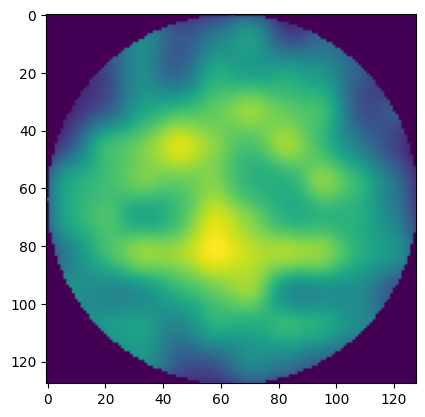

In [ ]:
plt.imshow(torch.sum(Phi.complex_amplitude.abs(), dim=0))